In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# Load the dataset
df = pd.read_csv('/content/sample_data/CO2 Emissions_Canada (2).csv')

print("Libraries imported and dataset loaded successfully.")
df.head()

Libraries imported and dataset loaded successfully.


,Make,Model,Vehicle Class,Engine Size(L),Cylinders,Transmission,Fuel Type,Fuel Consumption City (L/100 km),Fuel Consumption Hwy (L/100 km),Fuel Consumption Comb (L/100 km),Fuel Consumption Comb (mpg),CO2 Emissions(g/km)
0,ACURA,ILX,COMPACT,2.0,4,AS5,Z,9.9,6.7,8.5,33,196
1,ACURA,ILX,COMPACT,2.4,4,M6,Z,11.2,7.7,9.6,29,221
2,ACURA,ILX HYBRID,COMPACT,1.5,4,AV7,Z,6.0,5.8,5.9,48,136
3,ACURA,MDX 4WD,SUV - SMALL,3.5,6,AS6,Z,12.7,9.1,11.1,25,255
4,ACURA,RDX AWD,SUV - SMALL,3.5,6,AS6,Z,12.1,8.7,10.6,27,244


## Feature and Target Selection



In [ ]:
features = ['Engine Size(L)', 'Cylinders', 'Fuel Consumption Comb (L/100 km)']
target = 'CO2 Emissions(g/km)'

X = df[features]
y = df[target]

print("Features (X) and target (y) selected successfully.")
print("First 5 rows of X:")
print(X.head())
print("\nFirst 5 rows of y:")
print(y.head())

Features (X) and target (y) selected successfully.
First 5 rows of X:
   Engine Size(L)  Cylinders  Fuel Consumption Comb (L/100 km)
0             2.0          4                               8.5
1             2.4          4                               9.6
2             1.5          4                               5.9
3             3.5          6                              11.1
4             3.5          6                              10.6

First 5 rows of y:
0    196
1    221
2    136
3    255
4    244
Name: CO2 Emissions(g/km), dtype: int64


## Train-Test Split




In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Data split into training and testing sets successfully.")
print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

Data split into training and testing sets successfully.
Shape of X_train: (5908, 3)
Shape of X_test: (1477, 3)
Shape of y_train: (5908,)
Shape of y_test: (1477,)


## Train Linear Regression Model




In [ ]:
model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Linear Regression model trained and predictions made successfully.")
print("First 5 predicted values (y_pred):")
print(y_pred[:5])

Linear Regression model trained and predictions made successfully.
First 5 predicted values (y_pred):
[251.24550119 322.26694904 323.04820118 300.76153071 287.36197288]


## Visualize Actual vs. Predicted CO2 Emissions




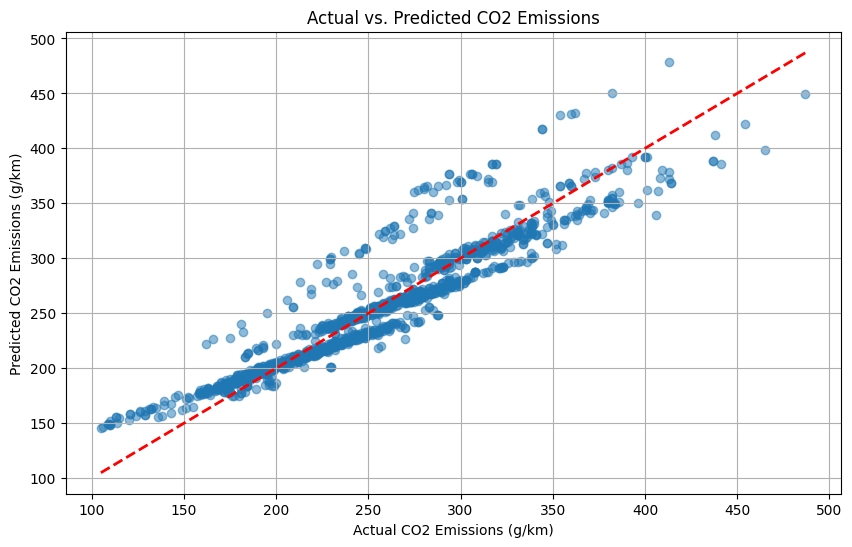

In [ ]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual CO2 Emissions (g/km)')
plt.ylabel('Predicted CO2 Emissions (g/km)')
plt.title('Actual vs. Predicted CO2 Emissions')
plt.grid(True)
plt.show()

In [ ]:
r_squared = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print(f"R-squared Score: {r_squared:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")

R-squared Score: 0.8773
Mean Absolute Error (MAE): 13.5173
Root Mean Squared Error (RMSE): 20.5407


## Visualize Correlation Heatmap




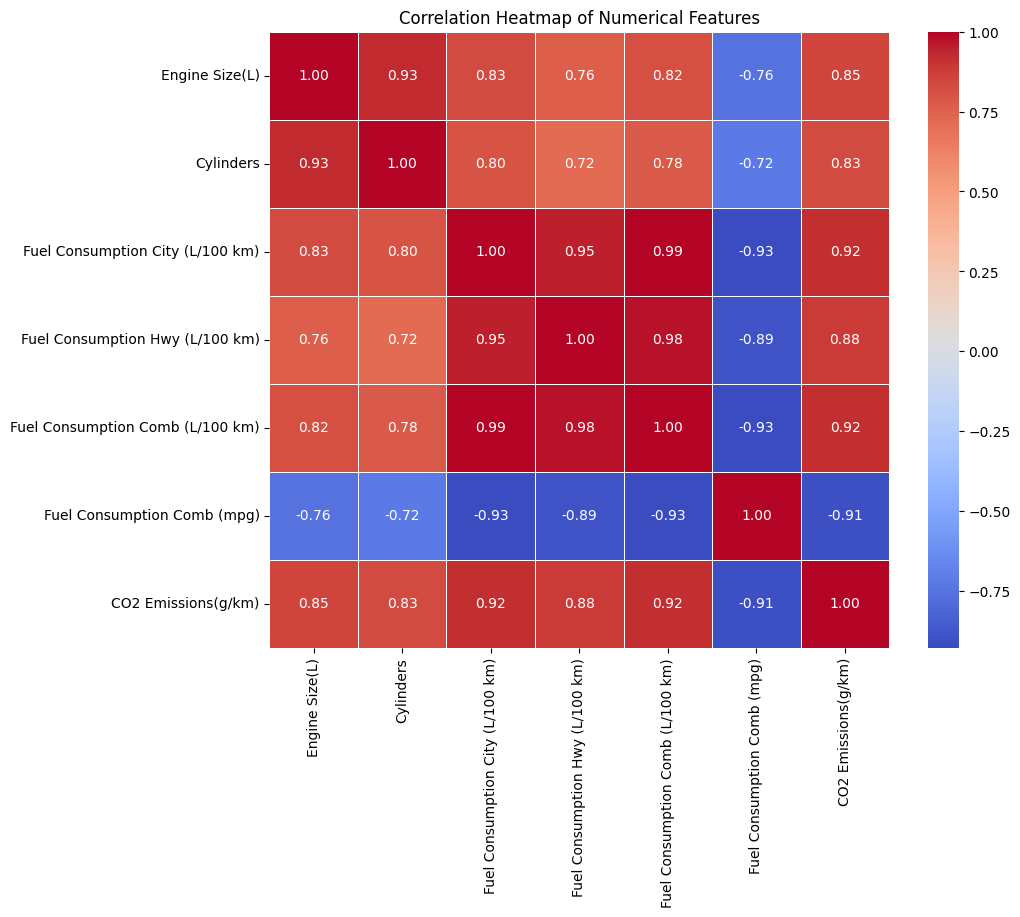

In [ ]:
numerical_df = df.select_dtypes(include=np.number)
corr = numerical_df.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

/tmp/ipython-input-1417807973.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_co2_by_class.index, y=avg_co2_by_class.values, palette='viridis')


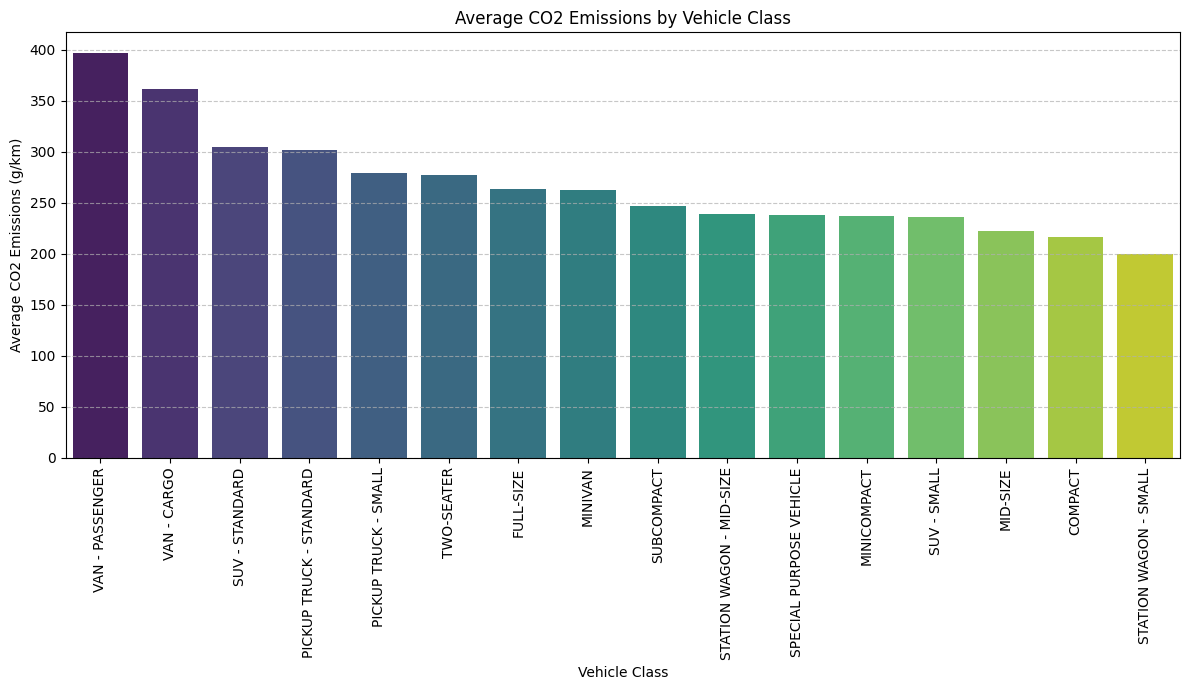

In [ ]:
avg_co2_by_class = df.groupby('Vehicle Class')['CO2 Emissions(g/km)'].mean().sort_values(ascending=False)

plt.figure(figsize=(12, 7))
sns.barplot(x=avg_co2_by_class.index, y=avg_co2_by_class.values, palette='viridis')
plt.xlabel('Vehicle Class')
plt.ylabel('Average CO2 Emissions (g/km)')
plt.title('Average CO2 Emissions by Vehicle Class')
plt.xticks(rotation=90)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

**Reasoning**:
The previous `barplot` call generated a `FutureWarning` because `palette` was used without `hue`. To address this, I will explicitly set `hue` to the `Vehicle Class` index and `legend` to `False` as suggested by the warning.



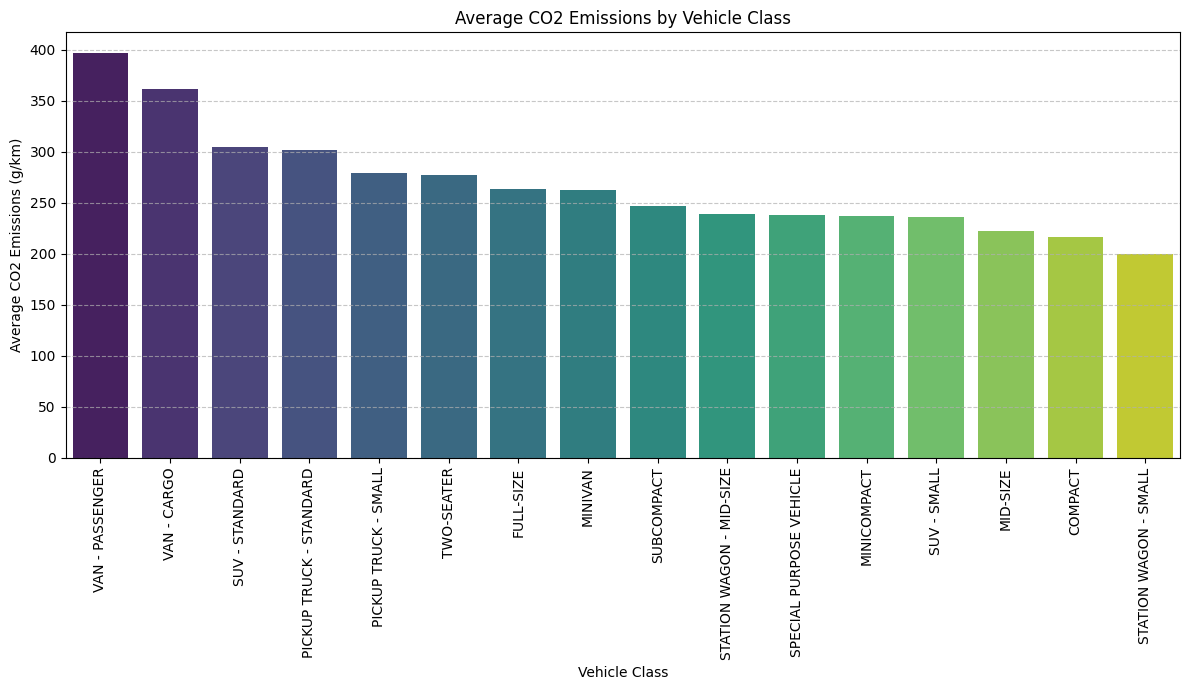

In [ ]:
avg_co2_by_class = df.groupby('Vehicle Class')['CO2 Emissions(g/km)'].mean().sort_values(ascending=False)

plt.figure(figsize=(12, 7))
sns.barplot(x=avg_co2_by_class.index, y=avg_co2_by_class.values, hue=avg_co2_by_class.index, palette='viridis', legend=False)
plt.xlabel('Vehicle Class')
plt.ylabel('Average CO2 Emissions (g/km)')
plt.title('Average CO2 Emissions by Vehicle Class')
plt.xticks(rotation=90)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

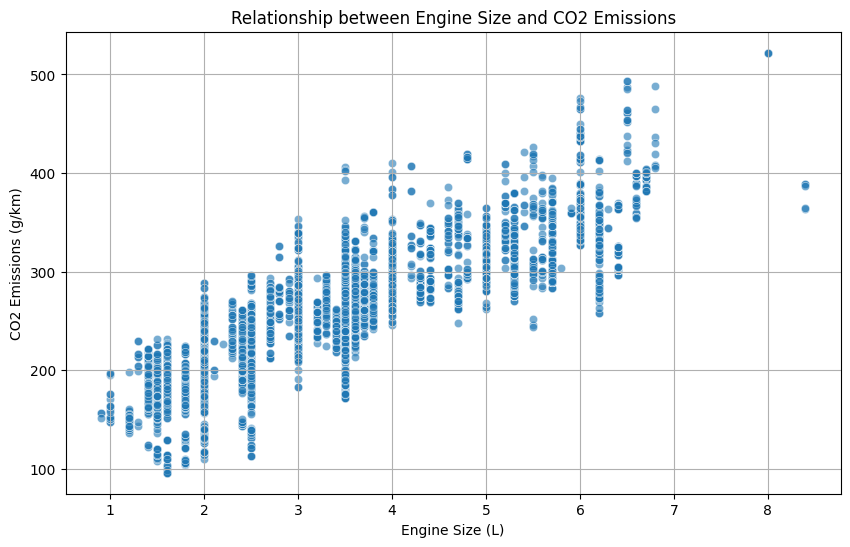

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Engine Size(L)', y='CO2 Emissions(g/km)', data=df, alpha=0.6)
plt.title('Relationship between Engine Size and CO2 Emissions')
plt.xlabel('Engine Size (L)')
plt.ylabel('CO2 Emissions (g/km)')
plt.grid(True)
plt.show()

## Visualize Engine Size vs. CO2 Emission



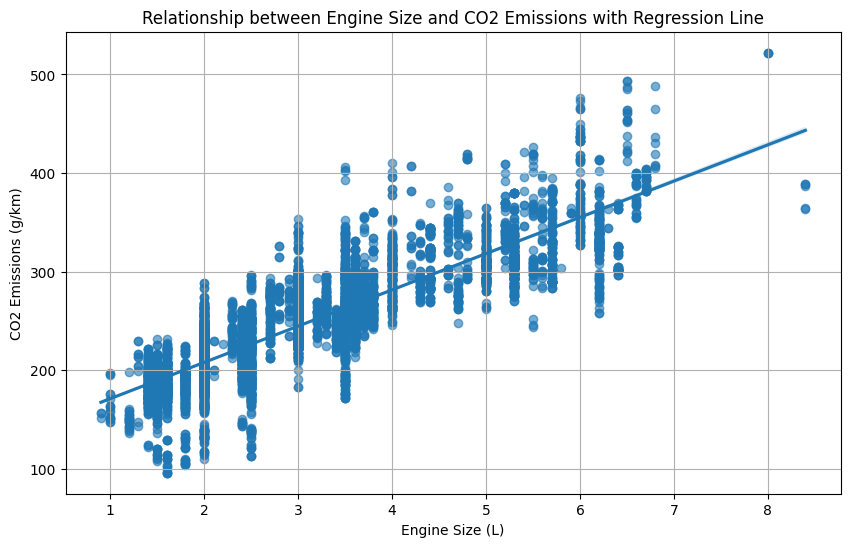

In [ ]:
plt.figure(figsize=(10, 6))
sns.regplot(x='Engine Size(L)', y='CO2 Emissions(g/km)', data=df, scatter_kws={'alpha':0.6})
plt.title('Relationship between Engine Size and CO2 Emissions with Regression Line')
plt.xlabel('Engine Size (L)')
plt.ylabel('CO2 Emissions (g/km)')
plt.grid(True)
plt.show()

## Define CO2 Emission Categories




In [ ]:
low_threshold = df['CO2 Emissions(g/km)'].quantile(0.33)
high_threshold = df['CO2 Emissions(g/km)'].quantile(0.66)

def get_emission_category(emissions):
    if emissions <= low_threshold:
        return 'Low'
    elif emissions <= high_threshold:
        return 'Medium'
    else:
        return 'High'

df['Emission Catagory'] = df['CO2 Emissions(g/km)'].apply(get_emission_category)
df['Emission Catagory'] = pd.Categorical(df['Emission Catagory'], categories=['Low', 'Medium', 'High'], ordered=True)

print(" 'Emission Catagory' column created successfully.")
print(df[['CO2 Emissions(g/km)', 'Emission Catagory']].head())

 'Emission Catagory' column created successfully.
   CO2 Emissions(g/km) Emission Catagory
0                  196               Low
1                  221            Medium
2                  136               Low
3                  255            Medium
4                  244            Medium


## Prepare Features and Target for KNN



In [ ]:
knn_features = ['Engine Size(L)', 'Cylinders', 'Fuel Consumption Comb (L/100 km)']
X_knn = df[knn_features]
y_knn = df['Emission Catagory']

print("Features (X_knn) and target (y_knn) selected successfully for KNN.")
print("First 5 rows of X_knn:")
print(X_knn.head())
print("\nFirst 5 rows of y_knn:")
print(y_knn.head())

Features (X_knn) and target (y_knn) selected successfully for KNN.
First 5 rows of X_knn:
   Engine Size(L)  Cylinders  Fuel Consumption Comb (L/100 km)
0             2.0          4                               8.5
1             2.4          4                               9.6
2             1.5          4                               5.9
3             3.5          6                              11.1
4             3.5          6                              10.6

First 5 rows of y_knn:
0       Low
1    Medium
2       Low
3    Medium
4    Medium
Name: Emission Catagory, dtype: category
Categories (3, object): ['Low' < 'Medium' < 'High']


## Split Data for KNN and Scale Features



In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Split data into training and testing sets
X_train_knn, X_test_knn, y_train_knn, y_test_knn = train_test_split(X_knn, y_knn, test_size=0.2, random_state=42)

# Initialize StandardScaler
scaler = StandardScaler()

# Fit and transform X_train_knn, then transform X_test_knn
X_train_scaled_knn = scaler.fit_transform(X_train_knn)
X_test_scaled_knn = scaler.transform(X_test_knn)

print("Data split and scaled successfully for KNN.")
print(f"Shape of X_train_scaled_knn: {X_train_scaled_knn.shape}")
print(f"Shape of X_test_scaled_knn: {X_test_scaled_knn.shape}")
print("\nFirst 5 rows of X_train_scaled_knn:")
print(X_train_scaled_knn[:5])

Data split and scaled successfully for KNN.
Shape of X_train_scaled_knn: (5908, 3)
Shape of X_test_scaled_knn: (1477, 3)

First 5 rows of X_train_scaled_knn:
[[-0.12149345  0.20534188 -0.37681659]
 [ 0.6141664   0.20534188  0.59257065]
 [-0.12149345  0.20534188  0.24636092]
 [ 0.17277049  0.20534188 -0.41143756]
 [-0.85715331 -0.88513888 -0.79226826]]


## Train K-Nearest Neighbors Classifier



In [ ]:
from sklearn.neighbors import KNeighborsClassifier

# Instantiate KNeighborsClassifier
knn_model = KNeighborsClassifier(n_neighbors=5)

# Train the KNN model
knn_model.fit(X_train_scaled_knn, y_train_knn)

print("K-Nearest Neighbors Classifier trained successfully.")

K-Nearest Neighbors Classifier trained successfully.


In [ ]:
y_pred_knn = knn_model.predict(X_test_scaled_knn)

print("Predictions made on the test set for KNN model.")
print("First 5 predicted emission categories:")
print(y_pred_knn[:5])

Predictions made on the test set for KNN model.
First 5 predicted emission categories:
['Medium' 'High' 'High' 'High' 'High']


In [ ]:
from sklearn.metrics import classification_report, accuracy_score

# Evaluate the KNN model
accuracy = accuracy_score(y_test_knn, y_pred_knn)
report = classification_report(y_test_knn, y_pred_knn)

print(f"KNN Model Accuracy: {accuracy:.4f}")
print("\nClassification Report:")
print(report)

KNN Model Accuracy: 0.9607

Classification Report:
              precision    recall  f1-score   support

        High       0.96      0.98      0.97       471
         Low       0.97      0.97      0.97       502
      Medium       0.96      0.94      0.95       504

    accuracy                           0.96      1477
   macro avg       0.96      0.96      0.96      1477
weighted avg       0.96      0.96      0.96      1477



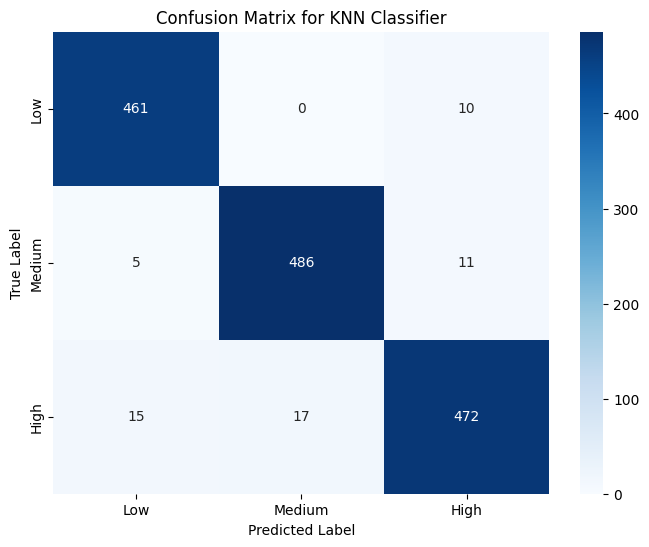

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Generate the confusion matrix
cm = confusion_matrix(y_test_knn, y_pred_knn)

# Get the unique class labels from the target variable
class_labels = y_test_knn.cat.categories

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
plt.title('Confusion Matrix for KNN Classifier')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

## Visualize KNN Classification in Feature Space


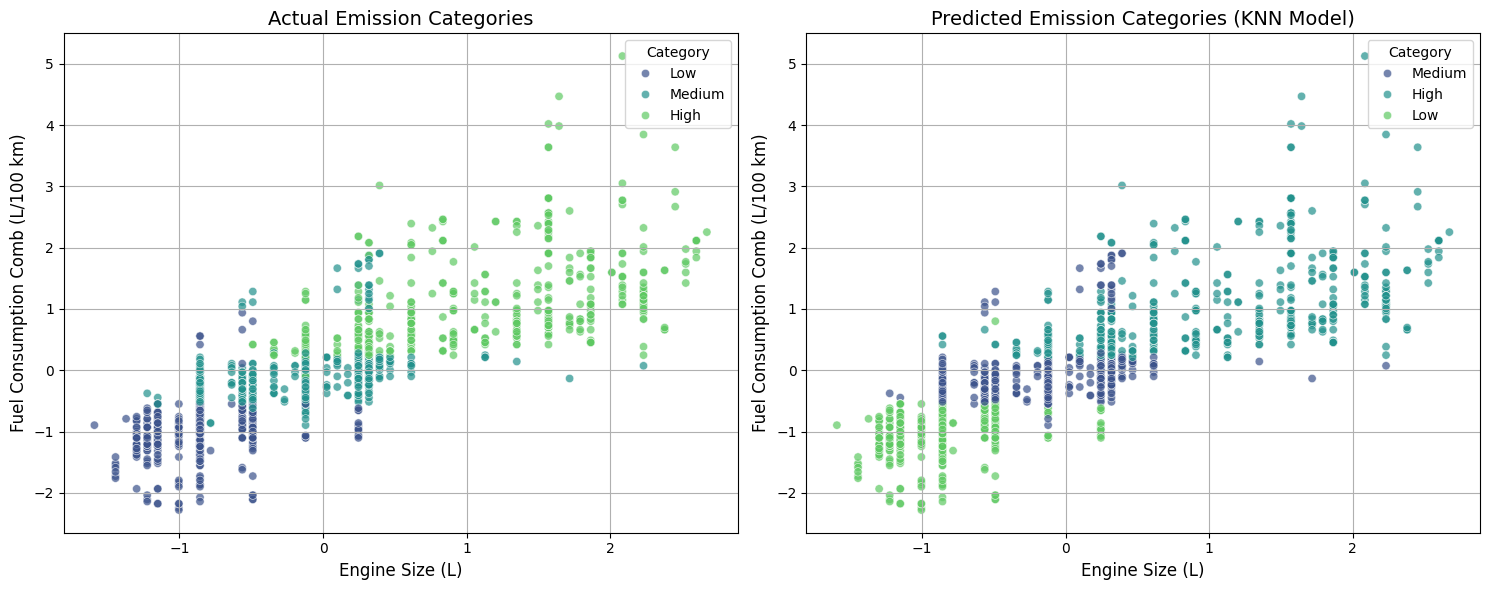

In [ ]:
plt.figure(figsize=(15, 6))

# Create a DataFrame for easier plotting with original feature names
plot_df = pd.DataFrame(X_test_scaled_knn, columns=X_knn.columns)
plot_df['Actual_Category'] = y_test_knn.values
plot_df['Predicted_Category'] = y_pred_knn

# Plot Actual Categories
plt.subplot(1, 2, 1) # 1 row, 2 columns, 1st plot
sns.scatterplot(
    x='Engine Size(L)',
    y='Fuel Consumption Comb (L/100 km)',
    hue='Actual_Category',
    data=plot_df,
    palette='viridis',
    alpha=0.7
)
plt.title('Actual Emission Categories', fontsize=14)
plt.xlabel('Engine Size (L)', fontsize=12)
plt.ylabel('Fuel Consumption Comb (L/100 km)', fontsize=12)
plt.legend(title='Category')
plt.grid(True)

# Plot Predicted Categories
plt.subplot(1, 2, 2) # 1 row, 2 columns, 2nd plot
sns.scatterplot(
    x='Engine Size(L)',
    y='Fuel Consumption Comb (L/100 km)',
    hue='Predicted_Category',
    data=plot_df,
    palette='viridis',
    alpha=0.7
)
plt.title('Predicted Emission Categories (KNN Model)', fontsize=14)
plt.xlabel('Engine Size (L)', fontsize=12)
plt.ylabel('Fuel Consumption Comb (L/100 km)', fontsize=12)
plt.legend(title='Category')
plt.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
import ipywidgets as widgets
from IPython.display import display, clear_output

# 1. Prepare Categorization Logic (KNN context)
# We define thresholds based on the dataset to show which category the car falls into
low_threshold = df['CO2 Emissions(g/km)'].quantile(0.33)
high_threshold = df['CO2 Emissions(g/km)'].quantile(0.66)

def get_emission_category(emissions):
    if emissions <= low_threshold: return "Low Emission (Eco-Friendly)"
    elif emissions <= high_threshold: return "Medium Emission"
    else: return "High Emission"

# 2. Setup UI Widgets
model_dropdown = widgets.Dropdown(
    options=sorted(df['Model'].unique()),
    description='Car Model:',
    disabled=False,
)

button = widgets.Button(description="Analyze Car", button_style='success')
output = widgets.Output()

def on_button_clicked(b):
    with output:
        clear_output()
        # Filter data for the selected model
        selected_car = df[df['Model'] == model_dropdown.value].iloc[0]

        print(f"--- Technical Specifications for {model_dropdown.value} ---")
        print(f"Make: {selected_car['Make']}")
        print(f"Vehicle Class: {selected_car['Vehicle Class']}")
        print(f"Engine Size (L): {selected_car['Engine Size(L)']}")
        print(f"Cylinders: {selected_car['Cylinders']}")
        print(f"Transmission: {selected_car['Transmission']}")
        print(f"Fuel Consumption (Comb L/100km): {selected_car['Fuel Consumption Comb (L/100 km)']}")

        # 3. Predict/Classify
        # Use the model you trained earlier in the notebook
        input_data = pd.DataFrame([[
            selected_car['Engine Size(L)'],
            selected_car['Cylinders'],
            selected_car['Fuel Consumption Comb (L/100 km)']
        ]], columns=['Engine Size(L)', 'Cylinders', 'Fuel Consumption Comb (L/100 km)'])

        prediction = model.predict(input_data)[0]
        category = get_emission_category(prediction)

        print(f"\n--- Analysis Results ---")
        print(f"Predicted CO2 Emissions: {prediction:.2f} g/km")
        print(f"Emission Category: {category}")

button.on_click(on_button_clicked)

# Display the UI
display(widgets.VBox([model_dropdown, button, output]))